In [25]:
from dotenv import load_dotenv
load_dotenv()

True

In [26]:
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from typing import TypedDict
import json
import re
import PyPDF2
import gradio as gr

llm = init_chat_model('google_genai:gemini-2.0-flash')

In [27]:
# Cell 2: Define state, tools (specialized agents), and supervisor function

class State(TypedDict):
    raw_input: dict
    structured_data: dict
    calculated_emissions: dict
    compliance_report: str
    recommendations: str
    next_step: str  # For supervisor to decide next tool

def extract_json(text: str) -> str:
    """Robust JSON extractor to handle common LLM output formats."""
    text = text.strip()
    # Remove code blocks if present
    text = re.sub(r'^``````$', '', text, flags=re.MULTILINE)
    # Find the JSON object
    match = re.search(r'\{[\s\S]*\}', text)
    if match:
        return match.group(0)
    raise ValueError("No valid JSON found in response")

def read_pdf(file_path: str) -> str:
    """Extract text from a PDF file."""
    try:
        with open(file_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            text = ""
            for page in reader.pages:
                text += page.extract_text() or ""
        return text[:2000]  # Truncate to avoid prompt length issues; adjust as needed
    except Exception as e:
        print(f"Error reading PDF {file_path}: {e}")
        return "PDF content unavailable."

# Define specialized agents as tools
@tool
def collect_data_tool(raw_input: dict) -> dict:
    """Tool to collect and structure emissions data."""
    print("Data Collection Tool called by Supervisor.")
    prompt = (
        "You are a data extraction agent for carbon tracking. "
        f"From this input: {raw_input}, extract structured data. "
        "Respond ONLY with valid JSON like: "
        "{\"energy_usage_kwh\": number, \"gas_usage_m3\": number, \"fuel_consumption_liters\": number, "
        "\"industry_type\": \"string\", \"location\": \"string\", \"reporting_period\": \"string\", "
        "\"material_kg\": number, \"emission_factor_kg_per_kg\": number}. "
        "NO additional text, explanations, code blocks, or markdown."
    )
    response = llm.invoke(prompt)
    try:
        json_str = extract_json(response.content)
        return json.loads(json_str)
    except (ValueError, json.JSONDecodeError) as e:
        print(f"Error in collect_data_tool: {e}")
        return {}

@tool
def calculate_emissions_tool(structured_data: dict) -> dict:
    """Tool to calculate emissions based on structured data."""
    print("Calculation Tool called by Supervisor.")
    prompt = (
        "You are an emissions calculation agent using IPCC methodologies. "
        f"Given this data: {structured_data}, compute Scope 1 (direct, e.g., gas + fuel), "
        "Scope 2 (indirect from electricity), and partial Scope 3 (supply chain) CO2e emissions in tonnes. "
        "Use factors: 0.4 kg CO2e/kWh for electricity, 2.0 kg CO2e/m3 for gas, 2.68 kg CO2e/liter for diesel, "
        "material_kg * emission_factor for Scope 3. Convert kg to tonnes (divide by 1000). "
        "Respond ONLY with valid JSON like: {\"scope_1\": number, \"scope_2\": number, \"scope_3\": number}. "
        "NO additional text, explanations, code blocks, or markdown."
    )
    response = llm.invoke(prompt)
    try:
        json_str = extract_json(response.content)
        return json.loads(json_str)
    except (ValueError, json.JSONDecodeError) as e:
        print(f"Error in calculate_emissions_tool: {e}")
        return {}

@tool
def make_report_tool(calculated_emissions: dict, industry_type: str, location: str, reporting_period: str) -> str:
    """Tool to generate compliance report, referring to provided regulatory documents."""
    print("Compliance Tool called by Supervisor.")
    # Load PDF contents
    efrag_text = read_pdf("EFRAG.pdf")
    sec_text = read_pdf("SEC final rule.pdf")
    csrd_text = read_pdf("csrd-2025.pdf")

    prompt = (
        "Generate a short carbon emissions compliance report."

        "- If the location is 'EU', base the report primarily on the EU CSRD and the most recent delegated acts (including 2025 update), summarizing the most relevant disclosure and reporting requirements for this region. Briefly mention US SEC requirements only as additional context if applicable."
        "- If the location is 'US', base the report primarily on the US SEC climate disclosure rule (2024/2025 Final Rule), summarizing the core requirements and referencing the relevant sections. Briefly mention EU CSRD only as additional international alignment if relevant."
        "- Adjust the summary based on whether the company size is 'SME' or 'Large', referencing any simplified or phased-in requirements for SMEs."
        f"Refer to these documents for standards: "
        f"EFRAG (EU): {efrag_text} "
        f"CSRD (US): {csrd_text} "
        f"SEC (US): {sec_text} "
        f"Use emissions: {calculated_emissions}, industry: {industry_type}, "
        f"location: {location}, period: {reporting_period}. "
        "Include totals, key references from the documents, and notes. Respond with plain text ONLY, no JSON or markdown."
    )
    response = llm.invoke(prompt)
    return response.content.strip()

@tool
def recommend_actions_tool(calculated_emissions: dict, industry_type: str, location: str, reporting_period: str) -> str:
    """Tool to recommend reduction strategies."""
    print("Recommendation Tool called by Supervisor.")
    prompt = (
        f"Suggest 2-3 practical, cost-effective carbon reduction strategies for an {industry_type}. "
        f"Base on emissions: {calculated_emissions}, industry: {industry_type}, location: {location}, period: {reporting_period}. "
        "Include estimated impact. Respond with plain text ONLY, no JSON or markdown."
    )
    response = llm.invoke(prompt)
    return response.content.strip()

# Supervisor agent function (LLM-powered to decide and call tools sequentially)
def supervisor_agent(state: State) -> State:
    print("Supervisor Agent: Deciding next step...")
    if not state.get("structured_data"):
        next_step = "collect_data"
    elif not state.get("calculated_emissions"):
        next_step = "calculate_emissions"
    elif not state.get("compliance_report"):
        next_step = "make_report"
    elif not state.get("recommendations"):
        next_step = "recommend_actions"
    else:
        next_step = "done"

    state["next_step"] = next_step
    return state

# Tool executor node
def tool_executor(state: State) -> State:
    next_step = state["next_step"]
    if next_step == "collect_data":
        result = collect_data_tool.invoke({"raw_input": state["raw_input"]})
        state["structured_data"] = result
    elif next_step == "calculate_emissions":
        result = calculate_emissions_tool.invoke({"structured_data": state["structured_data"]})
        state["calculated_emissions"] = result
    elif next_step == "make_report":
        result = make_report_tool.invoke({
            "calculated_emissions": state["calculated_emissions"],
            "industry_type": state["structured_data"].get("industry_type", "unknown"),
            "location": state["structured_data"].get("location", "unknown"),
            "reporting_period": state["structured_data"].get("reporting_period", "unknown")
        })
        state["compliance_report"] = result
    elif next_step == "recommend_actions":
        result = recommend_actions_tool.invoke({
            "calculated_emissions": state["calculated_emissions"],
            "industry_type": state["structured_data"].get("industry_type", "unknown"),
            "location": state["structured_data"].get("location", "unknown"),
            "reporting_period": state["structured_data"].get("reporting_period", "unknown")
        })
        state["recommendations"] = result
    return state


In [28]:
# Cell 3: Build LangGraph workflow with Supervisor, run with full sample input, and format outputs

# Define the graph
workflow = StateGraph(State)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("tools", tool_executor)

# Define edges: Supervisor decides, then calls tool, loops back until done
workflow.set_entry_point("supervisor")
workflow.add_edge("tools", "supervisor")
workflow.add_conditional_edges(
    "supervisor",
    lambda state: "tools" if state["next_step"] != "done" else END,
    {"tools": "tools", END: END}
)

# Compile the graph
app = workflow.compile()

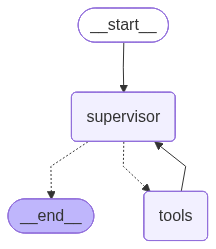

In [29]:
from IPython.display import display
display(app)

In [30]:
def gradio_main(
    electricity_kwh, other_utilities, supply_chain_data, industry_type, location, reporting_period
):
    # Parse utility
    utility_bill = f"Electricity: {electricity_kwh} kWh"
    if other_utilities.strip():
        utility_bill += ", " + other_utilities.strip()
    # Compose input
    raw_input = {
        "utility_bill": utility_bill,
        "supply_chain_data": supply_chain_data,
        "industry_type": industry_type,
        "location": location,
        "reporting_period": reporting_period,
    }
    # Set up initial state
    state = {
        "raw_input": raw_input,
        "structured_data": {},
        "calculated_emissions": {},
        "compliance_report": "",
        "recommendations": "",
        "next_step": ""
    }
    # Run workflow
    results = app.invoke(state)
    report = f"""### Structured Data:
{json.dumps(results.get('structured_data', {}), indent=2)}

### Calculated Emissions (tonnes CO2e):
{json.dumps(results.get('calculated_emissions', {}), indent=2)}

### Compliance Report:
{results.get('compliance_report', 'N/A')}

### Recommendations:
{results.get('recommendations', 'N/A')}
"""
    return report

iface = gr.Blocks()

with iface:
    gr.Markdown("# Carbon Emissions Agentic Analysis 🚀")

    with gr.Row():
        electricity_kwh = gr.Number(label="Electricity (kWh)", precision=0)
        other_utilities = gr.Textbox(
            label="Other (e.g., 'Gas: 700 m3, Diesel: 40 liters')"
        )

    supply_chain_data = gr.Textbox(
        label="Supply Chain Data (e.g., 'Purchased materials: 1000 kg with emission factor 0.5 kg CO2e per kg.')"
    )

    with gr.Row():
        industry_type = gr.Dropdown(label="Industry Type", choices=["SME", "Large"])
        location = gr.Dropdown(label="Location", choices=["EU", "US"])
        reporting_period = gr.Textbox(label="Reporting Period (e.g., October 2025)")

    submit = gr.Button("Analyze")
    output = gr.Textbox(label="Agentic Output Report", lines=20)

    submit.click(
        gradio_main,
        inputs=[
            electricity_kwh,
            other_utilities,
            supply_chain_data,
            industry_type,
            location,
            reporting_period,
        ],
        outputs=output
    )

iface.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
